# Benchmark Results Reader

This notebook reads and analyzes benchmark results from CSV files containing model performance metrics across multiple tasks and repeats.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

Specify the path to your benchmark results CSV file.

In [2]:
# Specify the path to your CSV file
csv_file = "simplepfn_ simple_pfn_16624966.0_10000_5repeats.csv"

# Load the data
df = pd.read_csv(csv_file)

print(f"Loaded {len(df)} rows and {len(df.columns)} columns")
print(f"\nDataset info:")
print(f"- Unique tasks: {df['task_id'].nunique()}")
print(f"- Unique repeats: {df['repeat_idx'].nunique()}")
print(f"- Checkpoint: {df['checkpoint_path'].iloc[0]}")

Loaded 115 rows and 51 columns

Dataset info:
- Unique tasks: 20
- Unique repeats: 5
- Checkpoint: final_model_with_bardist.pt


## Explore Data Structure

In [3]:
# Display first few rows
print("First few rows:")
df.head()

First few rows:


,process_id,timestamp,checkpoint_path,task_id,repeat_idx,dataset_shape,num_features,n_train,n_test,mse_lr,r2_lr,mse_rf,r2_rf,mse_ridge,r2_ridge,mse_lasso,r2_lasso,mse_enet,r2_enet,mse_huber,r2_huber,mse_bayesridge,r2_bayesridge,mse_svr,r2_svr,mse_knn,r2_knn,mse_dtr,r2_dtr,mse_extratrees,r2_extratrees,mse_gbrt,r2_gbrt,mse_adaboost,r2_adaboost,mse_mlp,r2_mlp,mse_pfn,r2_pfn,model,metric,mean,median,std,iqr,ci95_mean_low,ci95_mean_high,ci95_median_low,ci95_median_high,avg_rank_mse,avg_rank_r2
0,2210,2025-11-18T16:22:00.153470,final_model_with_bardist.pt,361072.0,0.0,"(8192, 22)",50.0,10000.0,10000.0,0.000052,0.000000,0.000000,1.000000,0.000055,0.000000,0.325404,0.000000,0.325404,0.000000,0.000001,0.000000,0.000053,0.000000,0.009929,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000001,0.000000,0.011547,0.000000,0.000015,0.000000,0.000001,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2210,2025-11-18T16:23:00.815570,final_model_with_bardist.pt,361073.0,0.0,"(15000, 27)",50.0,10000.0,10000.0,1.791791,-3.583774,0.445781,-0.140399,25.975403,-65.450470,0.428148,-0.095291,0.428148,-0.095291,0.524686,-0.342255,28.318562,-71.444756,4.896695,-11.526761,0.515422,-0.318557,0.508920,-0.301923,0.339673,0.131047,0.089308,0.771532,0.522611,-0.336948,0.038024,0.902727,0.252919,0.352979,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2210,2025-11-18T16:24:02.564094,final_model_with_bardist.pt,361073.0,1.0,"(15000, 27)",50.0,10000.0,10000.0,1.618138,-3.119190,0.425107,-0.082168,26.818747,-67.270737,0.433230,-0.102846,0.433230,-0.102846,0.701321,-0.785307,28.940519,-72.671997,4.947672,-11.594966,0.512512,-0.304669,0.509728,-0.297581,0.341582,0.130458,0.064677,0.835356,0.525240,-0.337070,0.009718,0.975262,0.041047,0.895510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2210,2025-11-18T16:25:02.583884,final_model_with_bardist.pt,361073.0,2.0,"(15000, 27)",50.0,10000.0,10000.0,38.580799,-96.403351,0.458015,-0.156332,29.724268,-74.043633,0.442232,-0.116485,0.442232,-0.116485,0.937883,-1.367834,30.475540,-75.940338,4.718356,-10.912241,0.515232,-0.300786,0.512228,-0.293201,0.345399,0.127985,0.078287,0.802353,0.477127,-0.204582,0.020336,0.948658,0.207846,0.475259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2210,2025-11-18T16:26:02.662432,final_model_with_bardist.pt,361073.0,3.0,"(15000, 27)",50.0,10000.0,10000.0,0.788454,-1.023493,0.492934,-0.265068,26.116774,-66.026215,0.438050,-0.124214,0.438050,-0.124214,0.674266,-0.730438,28.475632,-72.079994,4.701779,-11.066667,0.514696,-0.320917,0.511452,-0.312593,0.368972,0.053070,0.062578,0.839399,0.568196,-0.458222,0.083089,0.786761,0.234607,0.397903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Show column names and types
print("Column information:")
print(df.dtypes)

Column information:
process_id           object
timestamp            object
checkpoint_path      object
task_id             float64
repeat_idx          float64
dataset_shape        object
num_features        float64
n_train             float64
n_test              float64
mse_lr              float64
r2_lr               float64
mse_rf              float64
r2_rf               float64
mse_ridge           float64
r2_ridge            float64
mse_lasso           float64
r2_lasso            float64
mse_enet            float64
r2_enet             float64
mse_huber           float64
r2_huber            float64
mse_bayesridge      float64
r2_bayesridge       float64
mse_svr             float64
r2_svr              float64
mse_knn             float64
r2_knn              float64
mse_dtr             float64
r2_dtr              float64
mse_extratrees      float64
r2_extratrees       float64
mse_gbrt            float64
r2_gbrt             float64
mse_adaboost        float64
r2_adaboost         float64


In [5]:
# Get basic statistics
print("Basic statistics:")
df.describe()

Basic statistics:


,task_id,repeat_idx,num_features,n_train,n_test,mse_lr,r2_lr,mse_rf,r2_rf,mse_ridge,r2_ridge,mse_lasso,r2_lasso,mse_enet,r2_enet,mse_huber,r2_huber,mse_bayesridge,r2_bayesridge,mse_svr,r2_svr,mse_knn,r2_knn,mse_dtr,r2_dtr,mse_extratrees,r2_extratrees,mse_gbrt,r2_gbrt,mse_adaboost,r2_adaboost,mse_mlp,r2_mlp,mse_pfn,r2_pfn,mean,median,std,iqr,ci95_mean_low,ci95_mean_high,ci95_median_low,ci95_median_high,avg_rank_mse,avg_rank_r2
count,84.000000,84.000000,84.0,84.0,84.0,8.500000e+01,85.000000,85.000000,85.000000,8.400000e+01,84.000000,8.400000e+01,84.000000,8.400000e+01,84.000000,8.400000e+01,84.000000,8.400000e+01,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,8.400000e+01,84.000000,84.000000,84.000000,8.400000e+01,84.000000,85.000000,85.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,361097.285714,1.904762,50.0,10000.0,10000.0,8.157670e-01,-26.191608,0.115484,-9.001580,1.892760e+00,-27.203746,1.835996e-01,-7.982151,1.835996e-01,-7.982151,4.465347e-01,-29.603951,2.044867e+00,-29.600105,0.363231,-7.085187,0.118910,-9.344343,0.143983,-10.193594,0.115663,-9.327052,1.144370e-01,-10.443906,0.119492,-7.697240,9.063284e-02,-9.056752,0.101681,-8.814086,-6.755894,0.244690,22.996760,0.397213,-12.085955,-2.173952,0.132521,0.337059,7.950635,7.947778
std,55.777867,1.453032,0.0,0.0,0.0,4.226337e+00,71.182410,0.222175,35.923210,6.439017e+00,67.305603,1.740923e-01,28.707727,1.740923e-01,28.707727,1.258852e+00,87.037478,6.898510e+00,71.710725,1.121908,23.787795,0.244327,39.655810,0.239785,38.399069,0.218870,36.372341,2.354621e-01,36.932624,0.197900,29.323263,2.054679e-01,35.742653,0.210532,37.047035,9.618930,0.281344,25.803053,0.345266,15.389288,4.731836,0.192162,0.339303,2.538679,2.399093
min,361072.000000,0.000000,50.0,10000.0,10000.0,1.291585e-07,-257.109863,0.000000,-157.496422,1.125500e-07,-255.915314,1.537524e-08,-125.867554,1.537524e-08,-125.867554,8.306382e-18,-449.991445,1.412087e-07,-256.942902,0.003638,-103.567808,0.000000,-172.706558,0.000000,-166.725986,0.000000,-158.274363,2.350890e-07,-159.770559,0.000000,-127.614093,1.728479e-07,-160.725082,0.000001,-161.934509,-29.603951,-0.000409,0.174092,0.045043,-48.937212,-14.965037,-0.099108,-0.000214,3.952381,4.000000
25%,361077.000000,1.000000,50.0,10000.0,10000.0,1.477543e-02,0.000000,0.007252,0.377754,1.490106e-02,0.000000,5.535789e-02,-0.198745,5.535789e-02,-0.198745,1.690893e-02,-0.096365,1.478671e-02,0.000000,0.010036,-0.004234,0.010485,0.176381,0.014601,-0.298667,0.008234,0.422651,8.005862e-03,0.022198,0.013898,-0.004966,8.120125e-03,0.010223,0.011488,0.000000,-9.259477,0.026942,0.236543,0.106419,-18.080642,-2.352478,0.014053,0.036591,5.375000,5.862500
50%,361081.500000,2.000000,50.0,10000.0,10000.0,3.807816e-02,0.264697,0.016149,0.817459,3.818677e-02,0.239447,1.477974e-01,-0.000409,1.477974e-01,-0.000409,3.900636e-02,0.206935,3.808346e-02,0.239652,0.024855,0.494283,0.018658,0.714888,0.035229,0.604410,0.019351,0.740830,2.264565e-02,0.717740,0.036032,0.468310,2.028267e-02,0.760617,0.033202,0.396883,-3.497277,0.093402,15.343153,0.177783,-6.320654,-0.655422,0.023256,0.126617,8.050000,8.200000
75%,361086.000000,3.000000,50.0,10000.0,10000.0,1.386862e-01,0.744839,0.107840,0.920208,1.396865e-01,0.744607,2.122262e-01,-0.000048,2.122262e-01,-0.000048,1.624339e-01,0.702756,1.400150e-01,0.744595,0.086675,0.819663,0.088916,0.892029,0.153047,0.851583,0.100478,0.914955,8.104205e-02,0.856739,0.076943,0.739298,5.316302e-02,0.853588,0.065175,0.784749,0.137860,0.450453,36.792553,0.744604,0.091790,0.191932,0.213130,0.636031,9.975000,10.001786
max,361281.000000,4.000000,50.0,10000.0,10000.0,3.858080e+01,0.924755,0.878719,1.000000,2.972427e+01,0.925368,6.979616e-01,0.000000,6.979616e-01,0.000000,7.687206e+00,0.925294,3.047554e+01,0.924769,4.947672,0.967447,0.955650,1.000000,0.927979,1.000000,0.891161,1.000000,8.869227e-01,0.981877,0.740895,1.000000,9.449529e-01,0.980076,0.906862,0.976349,2.044867,0

## Extract Model Names and Metrics

The CSV contains MSE and R² scores for multiple models. Let's identify all the models.

In [6]:
# Extract model names from column names
mse_cols = [col for col in df.columns if col.startswith('mse_')]
r2_cols = [col for col in df.columns if col.startswith('r2_')]

model_names = [col.replace('mse_', '') for col in mse_cols]

print(f"Found {len(model_names)} models:")
for i, model in enumerate(model_names, 1):
    print(f"{i:2d}. {model}")

Found 15 models:
 1. lr
 2. rf
 3. ridge
 4. lasso
 5. enet
 6. huber
 7. bayesridge
 8. svr
 9. knn
10. dtr
11. extratrees
12. gbrt
13. adaboost
14. mlp
15. pfn


## Aggregate Results by Task

Calculate mean and standard deviation of metrics across repeats for each task.

In [7]:
# Group by task and calculate mean/std for MSE and R²
agg_results = df.groupby('task_id').agg({
    'num_features': 'first',
    'n_train': 'first',
    'n_test': 'first',
    **{f'mse_{model}': ['mean', 'std'] for model in model_names},
    **{f'r2_{model}': ['mean', 'std'] for model in model_names}
})

print("Aggregated results (first few rows):")
agg_results.head()

Aggregated results (first few rows):


num_features  n_train   n_test    mse_lr               mse_rf  \
                first    first    first      mean        std      mean   
task_id                                                                  
361072.0         50.0  10000.0  10000.0  0.000052        NaN  0.000000   
361073.0         50.0  10000.0  10000.0  8.609202  16.766097  0.446248   
361074.0         50.0  10000.0  10000.0  0.016046   0.004159  0.019947   
361075.0         50.0  10000.0  10000.0  0.001014   0.000141  0.000000   
361076.0         50.0  10000.0  10000.0  0.000002        NaN  0.000000   

                    mse_ridge               mse_lasso                \
               std       mean       std          mean           std   
task_id                                                               
361072.0       NaN   0.000055       NaN  3.254045e-01           NaN   
361073.0  0.032104  27.161263  1.515225  4.341776e-01  5.950421e-03   
361074.0  0.007416   0.016326  0.004158  1.951993e-01  2.421401e-03   
361075.0  0.000000   0.001016  0.000136  1.537532e-08  7.917850e-14   
361076.0       NaN   0.000002       NaN  1.547110e-03           NaN   

              mse_enet                   mse_huber           mse_bayesridge  \
                  mean           std          mean       std           mean   
task_id                                                                       
361072.0  3.254045e-01           NaN  1.003471e-06       NaN       0.000053   
361073.0  4.341776e-01  5.950421e-03  6.718943e-01  0.170269      29.108205   
361074.0  1.951993e-01  2.421401e-03  1.845160e-02  0.004484       0.016062   
361075.0  1.537532e-08  7.917850e-14  1.372573e-04  0.000061       0.001043   
361076.0  1.547110e-03           NaN  1.413686e-07       NaN       0.000002   

                     mse_svr             mse_knn             mse_dtr  \
               std      mean       std      mean       std      mean   
task_id                                                                
361072.0       NaN  0.009929       NaN  0.000000       NaN  0.000000   
361073.0  0.861822  4.756696  0.171075  0.514425  0.001162  0.510839   
361074.0  0.004155  0.012418  0.007373  0.016253  0.003400  0.061852   
361075.0  0.000105  0.010027  0.000044  0.000000  0.000000  0.000000   
361076.0       NaN  0.009957       NaN  0.000000       NaN  0.000000   

                   mse_extratrees            mse_gbrt           mse_adaboost  \
               std           mean       std      mean       std         mean   
task_id                                                                        
361072.0       NaN       0.000000       NaN  0.000001       NaN     0.011547   
361073.0  0.001439       0.360480  0.028429  0.063681  0.024912     0.532331   
361074.0  0.042223       0.019211  0.006540  0.025048  0.006680     0.035435   
361075.0  0.000000       0.000000  0.000000  0.000013  0.000014     0.001787   
361076.0       NaN       0.000000       NaN  0.000002       NaN     0.000026   

                     mse_mlp             mse_pfn                r2_lr  \
               std      mean       std      mean       std       mean   
task_id                                                                 
361072.0       NaN  0.000015       NaN  0.000001       NaN   0.000000   
361073.0  0.038031  0.038228  0.028056  0.208572  0.100359 -20.762528   
361074.0  0.013436  0.011468  0.007071  0.057192  0.008403   0.884164   
361075.0  0.002807  0.000031  0.000031  0.061528  0.120321   0.000000   
361076.0       NaN  0.000011       NaN  0.004506       NaN   0.000000   

                        r2_rf             r2_ridge            r2_lasso  \
                std      mean       std       mean       std      mean   
task_id                                                                  
361072.0        NaN  1.000000       NaN   0.000000       NaN  0.000000   
361073.0  42.314047 -0.138333  0.083306 -68.264857  3.441905 -0.107453   
361074.0   0.029221  0.855818  0.053394  

## Compare Model Performance

Create a summary showing mean MSE and R² for each model across all tasks.

In [8]:
# Calculate overall mean performance for each model
model_performance = pd.DataFrame({
    'Model': model_names,
    'Mean_MSE': [df[f'mse_{model}'].mean() for model in model_names],
    'Std_MSE': [df[f'mse_{model}'].std() for model in model_names],
    'Mean_R2': [df[f'r2_{model}'].mean() for model in model_names],
    'Std_R2': [df[f'r2_{model}'].std() for model in model_names]
})

# Sort by Mean_MSE (lower is better)
model_performance = model_performance.sort_values('Mean_MSE')
print("Model Performance Summary (sorted by MSE):")
model_performance

Model Performance Summary (sorted by MSE):


,Model,Mean_MSE,Std_MSE,Mean_R2,Std_R2
13,mlp,0.090633,0.205468,-9.056752,35.742653
14,pfn,0.101681,0.210532,-8.814086,37.047035
11,gbrt,0.114437,0.235462,-10.443906,36.932624
1,rf,0.115484,0.222175,-9.001580,35.923210
10,extratrees,0.115663,0.218870,-9.327052,36.372341
8,knn,0.118910,0.244327,-9.344343,39.655810
12,adaboost,0.119492,0.197900,-7.697240,29.323263
9,dtr,0.143983,0.239785,-10.193594,38.399069
3,lasso,0.183600,0.174092,-7.982151,28.707727
4,enet,0.183600,0.174092,-7.982151,28.707727


## Visualizations

### MSE Comparison Across Models

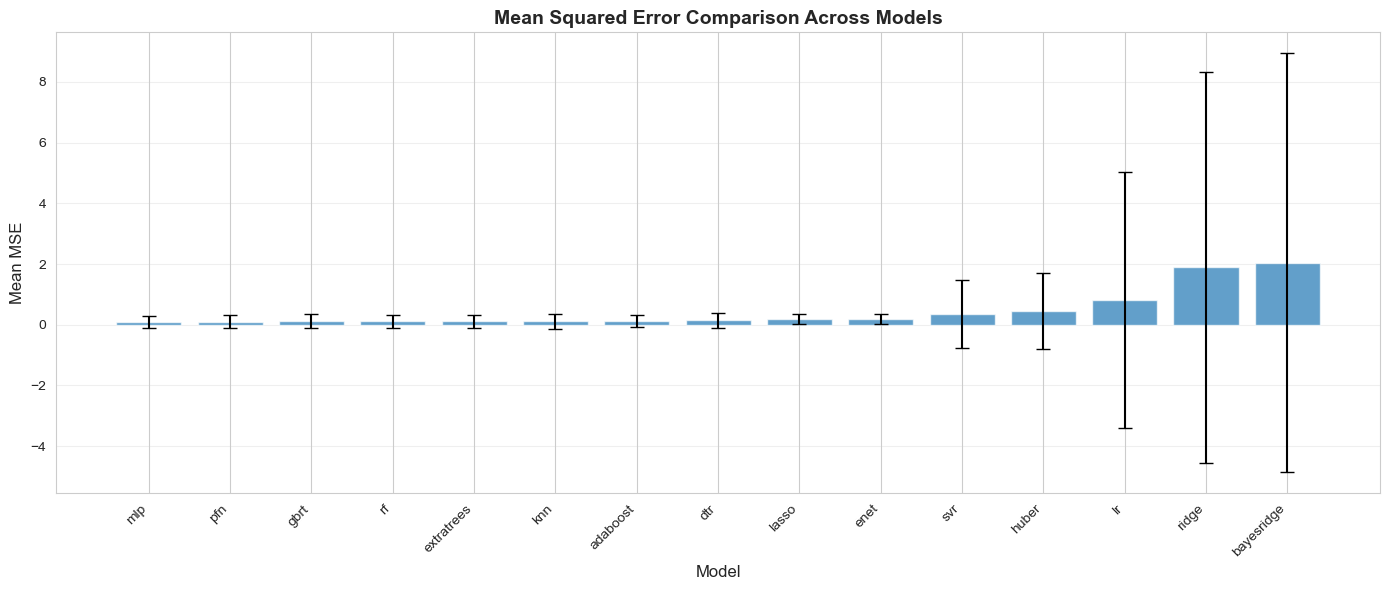

In [9]:
plt.figure(figsize=(14, 6))
plt.bar(model_performance['Model'], model_performance['Mean_MSE'], 
        yerr=model_performance['Std_MSE'], capsize=5, alpha=0.7)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean MSE', fontsize=12)
plt.title('Mean Squared Error Comparison Across Models', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

### R² Score Comparison

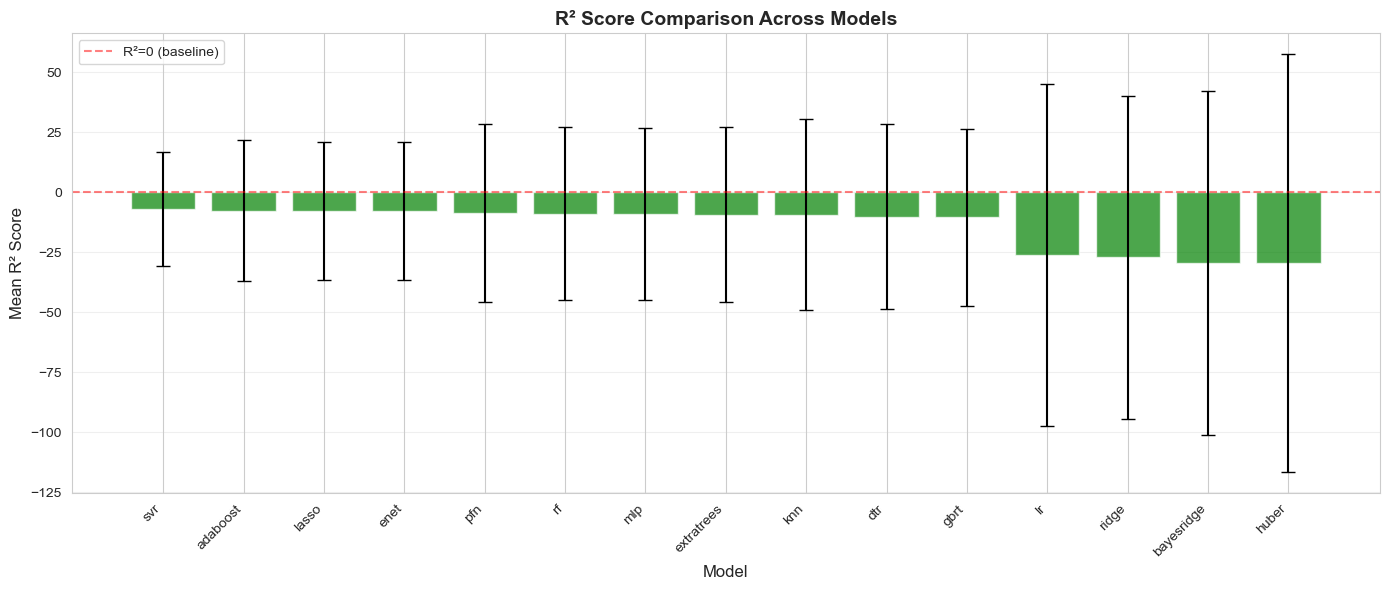

In [10]:
# Sort by R² (higher is better)
model_performance_r2 = model_performance.sort_values('Mean_R2', ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(model_performance_r2['Model'], model_performance_r2['Mean_R2'], 
        yerr=model_performance_r2['Std_R2'], capsize=5, alpha=0.7, color='green')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean R² Score', fontsize=12)
plt.title('R² Score Comparison Across Models', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='R²=0 (baseline)')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Performance Distribution Across Tasks

Box plots showing MSE distribution for each model.

/var/folders/ng/4_7_0hz56vnfj1yd8btkt5h80007z9/T/ipykernel_5327/1823960294.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(mse_data, labels=top_models, patch_artist=True)


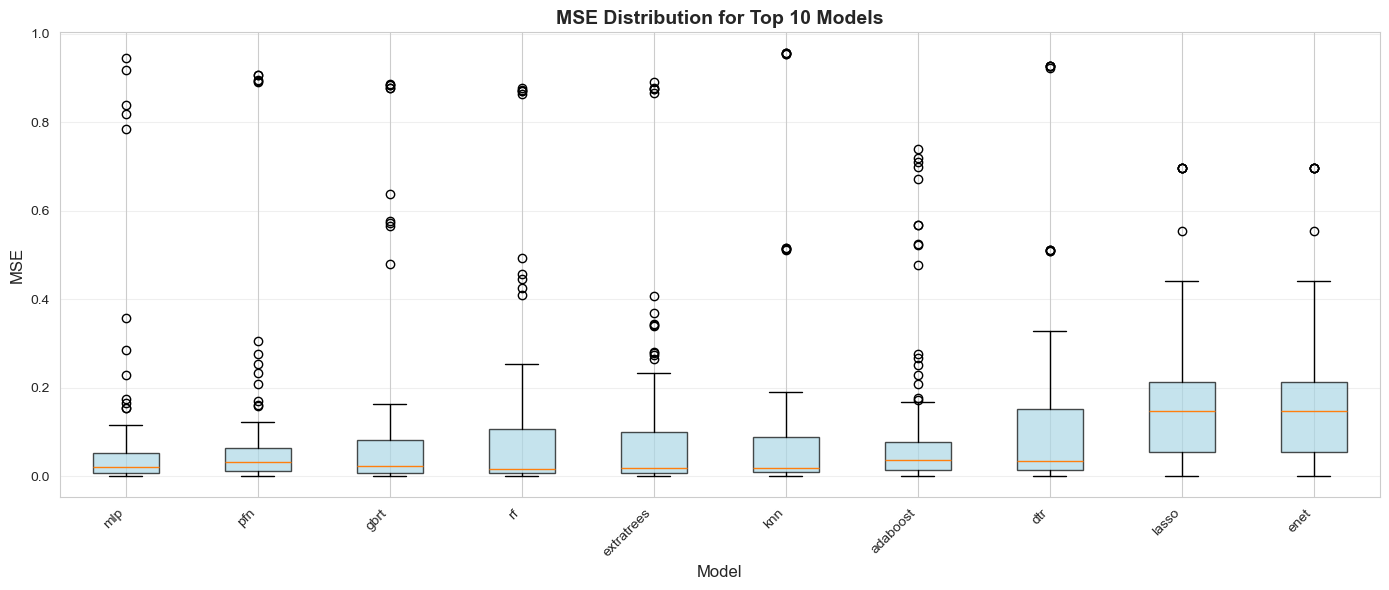

In [11]:
# Prepare data for box plot (showing top 10 models by mean MSE)
top_models = model_performance['Model'].head(10).tolist()
mse_data = [df[f'mse_{model}'].dropna() for model in top_models]

plt.figure(figsize=(14, 6))
bp = plt.boxplot(mse_data, labels=top_models, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)
plt.xlabel('Model', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('MSE Distribution for Top 10 Models', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Task-Level Analysis

Show performance for each task with all models.

In [14]:
# For each task, show which model performed best
task_best_models = []

for task_id in df['task_id'].unique():
    task_data = df[df['task_id'] == task_id]
    
    # Calculate mean MSE for each model on this task
    task_mse = {model: task_data[f'mse_{model}'].mean() for model in model_names}
    
    # Find best model (lowest MSE)
    best_model = min(task_mse, key=task_mse.get)
    best_mse = task_mse[best_model]
    
    # Get R² for best model
    best_r2 = task_data[f'r2_{best_model}'].mean()
    
    task_best_models.append({
        'task_id': task_id,
        'best_model': best_model,
        'best_mse': best_mse,
        'best_r2': best_r2,
        #'num_features': task_data['num_features'].iloc[0]
    })

task_summary = pd.DataFrame(task_best_models)
print("Best performing model for each task:")
task_summary

Best performing model for each task:


,task_id,best_model,best_mse,best_r2
0,361072.0,rf,0.000000,1.000000
1,361073.0,mlp,0.038228,0.902222
2,361074.0,mlp,0.011468,0.917378
3,361075.0,rf,0.000000,1.000000
4,361076.0,rf,0.000000,1.000000
5,361077.0,rf,0.009389,0.891102
6,361078.0,rf,0.018445,0.825539
7,361079.0,rf,0.007788,0.557687
8,361080.0,gbrt,0.014086,0.944519
9,361081.0,knn,0.004795,0.725965


## Win Rate Analysis

Count how many times each model was the best performer.

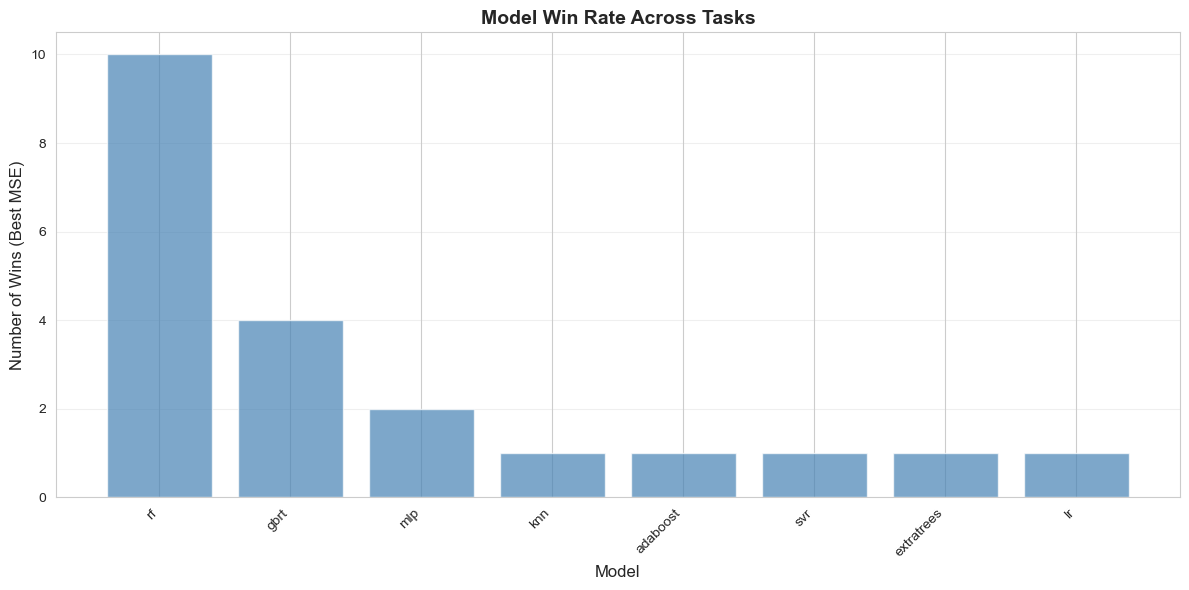


Total tasks: 21
Models that won at least once: 8

Win distribution:
best_model
rf            10
gbrt           4
mlp            2
knn            1
adaboost       1
svr            1
extratrees     1
lr             1
Name: count, dtype: int64


In [15]:
# Count wins for each model
win_counts = task_summary['best_model'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(win_counts.index, win_counts.values, alpha=0.7, color='steelblue')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Number of Wins (Best MSE)', fontsize=12)
plt.title('Model Win Rate Across Tasks', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal tasks: {len(task_summary)}")
print(f"Models that won at least once: {len(win_counts)}")
print(f"\nWin distribution:")
print(win_counts)

## Export Summary

Save the aggregated results to a new CSV file.

In [16]:
# Save model performance summary
output_file = "model_performance_summary.csv"
model_performance.to_csv(output_file, index=False)
print(f"Model performance summary saved to: {output_file}")

# Save task-level summary
task_output = "task_best_models.csv"
task_summary.to_csv(task_output, index=False)
print(f"Task-level summary saved to: {task_output}")

Model performance summary saved to: model_performance_summary.csv
Task-level summary saved to: task_best_models.csv
